In [1]:
!pip install pandas numpy matplotlib scikit-learn fairlearn notebook

  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached fqdn-1.5.1-py3-none-any.whl.metadata (1.4 kB)
  Using cached isoduration-20.11.0-py3-none-any.whl.metadata (5.7 kB)
  Using cached uri_template-1.3.0-py3-none-any.whl.metadata (8.8 kB)
Using cached narwhals-2.22.1-py3-none-any.whl (454 kB)
Using cached fqdn-1.5.1-py3-none-any.whl (9.1 kB)
Using cached isoduration-20.11.0-py3-none-any.whl (11 kB)
Using cached uri_template-1.3.0-py3-none-any.whl (11 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [fairlearn]/6 [isoduration]


In [2]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
 
from fairlearn.metrics import demographic_parity_difference


In [3]:
# Step 2: Create the Sample Dataset
data = {
    "Gender": [
        "Male","Male","Female","Male","Female",
        "Male","Female","Male","Female","Male",
        "Female","Male","Female","Male","Female",
        "Male","Female","Male","Female","Male"
    ],
    "Age": [
        35,42,38,29,31,45,28,33,40,36,
        30,50,27,39,44,41,32,47,36,34
    ],
    "Income": [
        75000,82000,68000,65000,62000,
        95000,54000,72000,76000,81000,
        60000,100000,52000,78000,73000,
        85000,61000,93000,70000,76000
    ],
    "CreditScore": [
        720,740,690,700,680,
        780,650,710,700,730,
        670,790,640,720,700,
        750,675,770,690,725
    ],
    "LoanAmount": [
        250000,300000,200000,180000,175000,
        350000,150000,220000,240000,280000,
        160000,400000,140000,260000,230000,
        310000,170000,360000,210000,245000
    ],
    "Approved": [
        1,1,0,1,0,1,0,1,1,1,
        0,1,0,1,1,1,0,1,0,1
    ]
}
 
df = pd.DataFrame(data)
df.head()


,Gender,Age,Income,CreditScore,LoanAmount,Approved
0,Male,35,75000,720,250000,1
1,Male,42,82000,740,300000,1
2,Female,38,68000,690,200000,0
3,Male,29,65000,700,180000,1
4,Female,31,62000,680,175000,0


In [4]:
# Step 3: Review the Dataset
df.info()
df.describe()
df["Gender"].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Gender       20 non-null     object
 1   Age          20 non-null     int64 
 2   Income       20 non-null     int64 
 3   CreditScore  20 non-null     int64 
 4   LoanAmount   20 non-null     int64 
 5   Approved     20 non-null     int64 
dtypes: int64(5), object(1)
memory usage: 1.1+ KB


Gender
Male      11
Female     9
Name: count, dtype: int64

In [6]:
# Step 4: Define Features, Label, and Sensitive Attribute
X = df[["Age", "Income", "CreditScore", "LoanAmount"]]
y = df["Approved"]
 
sensitive_feature = df["Gender"]


In [7]:
# Step 5: Split the Dataset
X_train, X_test, y_train, y_test, gender_train, gender_test = train_test_split(
    X,
    y,
    sensitive_feature,
    test_size=0.30,
    random_state=42
)


In [8]:
# Step 6: Train the Model
model = DecisionTreeClassifier(random_state=42)
 
model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [9]:
# Step 7: Generate Predictions
y_pred = model.predict(X_test)
 
y_pred


array([1, 1, 1, 1, 1, 1])

In [10]:
# Step 8: Evaluate Model Accuracy
accuracy = accuracy_score(y_test, y_pred)
 
print(f"Model Accuracy: {accuracy:.2f}")


Model Accuracy: 1.00


In [11]:
# Step 9: Create Results DataFrame
results = X_test.copy()
results["Gender"] = gender_test.values
results["Actual"] = y_test.values
results["Prediction"] = y_pred
results



,Age,Income,CreditScore,LoanAmount,Gender,Actual,Prediction
0,35,75000,720,250000,Male,1,1
17,47,93000,770,360000,Male,1,1
15,41,85000,750,310000,Male,1,1
1,42,82000,740,300000,Male,1,1
8,40,76000,700,240000,Female,1,1
5,45,95000,780,350000,Male,1,1


In [12]:
# Step 10: Calculate Approval Rates by Gender
approval_rates = results.groupby("Gender")["Prediction"].mean()
 
approval_rates


Gender
Female    1.0
Male      1.0
Name: Prediction, dtype: float64

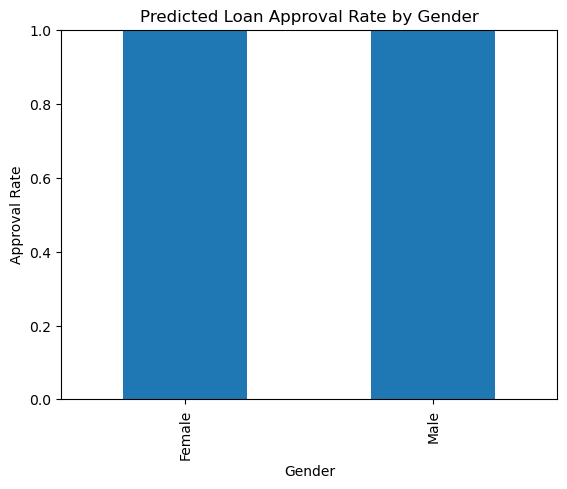

In [15]:
# Step 11: Visualize Approval Rates
approval_rates.plot(
    kind="bar",
    title="Predicted Loan Approval Rate by Gender"
)
 
plt.ylabel("Approval Rate")
plt.xlabel("Gender")
plt.ylim(0, 1)
plt.show()
 



In [16]:
# Step 12: Calculate Demographic Parity Difference
male_rate = approval_rates.get("Male", 0)
female_rate = approval_rates.get("Female", 0)
 
demographic_parity_manual = abs(male_rate - female_rate)
 
print(f"Manual Demographic Parity Difference: {demographic_parity_manual:.2f}")
 


Manual Demographic Parity Difference: 0.00


In [17]:
# Step 13: Calculate Disparate Impact Ratio
disparate_impact = female_rate / male_rate if male_rate != 0 else 0
 
print(f"Disparate Impact Ratio: {disparate_impact:.2f}")
 


Disparate Impact Ratio: 1.00


In [18]:
# Step 14: Apply the 80% Rule
if disparate_impact >= 0.80:
    print("Result: Passes the 80% Rule")
else:
    print("Result: Potential fairness concern")


Result: Passes the 80% Rule


In [19]:
# Step 15: Use Fairlearn
dp_difference = demographic_parity_difference(
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=gender_test
)
 
print(f"Fairlearn Demographic Parity Difference: {dp_difference:.2f}")


Fairlearn Demographic Parity Difference: 0.00


In [20]:
# Step 16: Create a Fairness Summary
fairness_summary = pd.DataFrame({
    "Metric": [
        "Model Accuracy",
        "Male Approval Rate",
        "Female Approval Rate",
        "Demographic Parity Difference",
        "Disparate Impact Ratio"
    ],
    "Value": [
        round(accuracy, 2),
        round(male_rate, 2),
        round(female_rate, 2),
        round(demographic_parity_manual, 2),
        round(disparate_impact, 2)
    ]
})
 
fairness_summary
 


,Metric,Value
0,Model Accuracy,1.0
1,Male Approval Rate,1.0
2,Female Approval Rate,1.0
3,Demographic Parity Difference,0.0
4,Disparate Impact Ratio,1.0


In [21]:
# Step 17: Save the Fairness Report
report = f"""
# Fairness Assessment Report
 
## Model
Decision Tree Loan Approval Model
 
## Protected Attribute
Gender
 
## Model Accuracy
{accuracy:.2f}
 
## Approval Rates
Male Approval Rate: {male_rate:.2f}
 
Female Approval Rate: {female_rate:.2f}
 
## Fairness Metrics
Demographic Parity Difference: {demographic_parity_manual:.2f}
 
Disparate Impact Ratio: {disparate_impact:.2f}
 
## Findings
The model shows different approval rates across gender groups. 
If the disparate impact ratio is below 0.80, this may indicate a potential fairness concern.
 
## Recommendations
The organization should review the training data, conduct additional fairness analysis, evaluate other protected attributes, and consider bias mitigation techniques before deployment.
"""
 
with open("fairness_report.md", "w") as file:
    file.write(report)
 
print("Fairness report saved as fairness_report.md")


Fairness report saved as fairness_report.md
